## 13. Load data from Google Drive

In [1]:
# === Load from Google Drive ===
import pandas as pd
import joblib
from google.colab import drive

drive.mount('/content/drive')

# Load processed feature and label sets
X_train = pd.read_csv("/content/drive/MyDrive/X_train_processed.csv")
X_test = pd.read_csv("/content/drive/MyDrive/X_test_processed.csv")
y_train = pd.read_csv("/content/drive/MyDrive/y_train_processed.csv").squeeze()
y_test = pd.read_csv("/content/drive/MyDrive/y_test_processed.csv").squeeze()

# Load scaler
scaler = joblib.load("/content/drive/MyDrive/standard_scaler.pkl")

# === Align test columns with train (important after one-hot encoding) ===
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

Mounted at /content/drive


## 14. Baseline Modeling on Preprocessed Data

Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating KNN...
Evaluating Gaussian Naive Bayes...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating Extra Trees...
Evaluating Balanced Random Forest...
Evaluating Easy Ensemble...

==== Final Test Set Evaluation ====


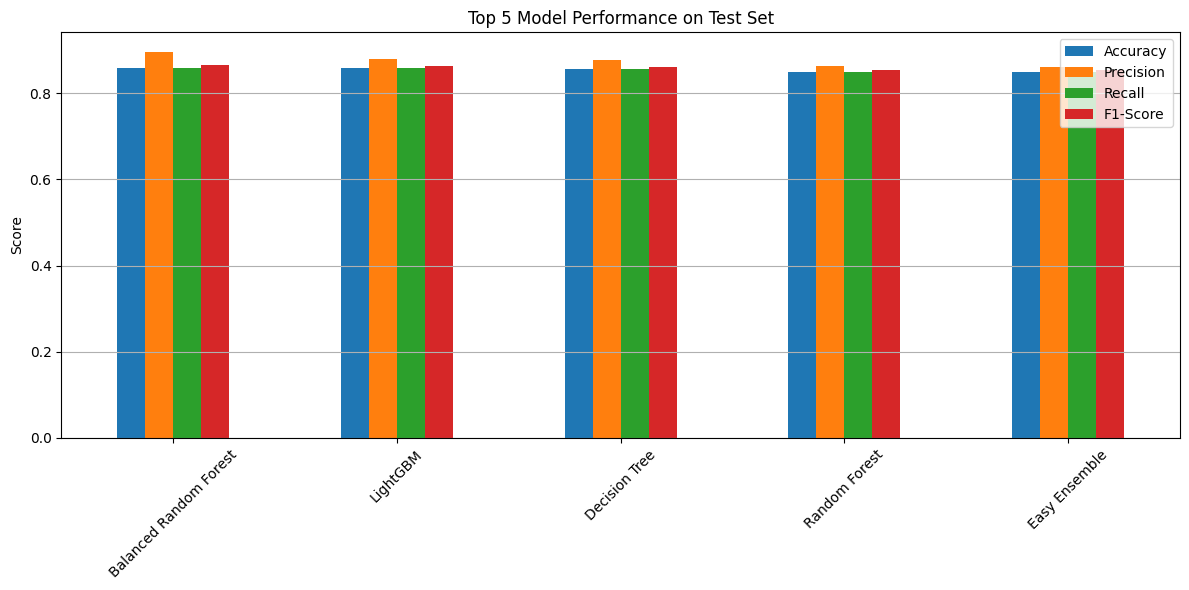

In [2]:
# === Modeling and Evaluation ===
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.ensemble import (
    BalancedRandomForestClassifier, EasyEnsembleClassifier
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== SET YOUR SAMPLING RATIO HERE ====
subset_ratio = 0.2  # use 20% of train/test data

# ==== Subsample X_train and y_train ====
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=subset_ratio, stratify=y_train, random_state=42
)

# ==== Subsample X_test and y_test ====
X_test_small, _, y_test_small, _ = train_test_split(
    X_test, y_test, train_size=subset_ratio, stratify=y_test, random_state=42
)

# ==== Use part of X_train_small for cross-validation ====
X_cv_sample, _, y_cv_sample, _ = train_test_split(
    X_train_small, y_train_small, train_size=subset_ratio, stratify=y_train_small, random_state=42
)

# ==== Define Stratified K-Fold and scoring ====
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted', zero_division=0),
    'f1': make_scorer(f1_score, average='weighted', zero_division=0),
}

# ==== Define model groups ====
group1 = {
    'Dummy Classifier': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=25, max_depth=10, n_jobs=-1, random_state=42),
}
group2 = {
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gaussian Naive Bayes': GaussianNB()
}
group3 = {
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42),
    'XGBoost': XGBClassifier(eval_metric="mlogloss", n_estimators=50, learning_rate=0.1, max_depth=3, n_jobs=-1, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, learning_rate=0.1, max_depth=10, random_state=42, verbose=-1, n_jobs=-1),
}
group4 = {
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42),
    'Balanced Random Forest': BalancedRandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42),
    'Easy Ensemble': EasyEnsembleClassifier(n_estimators=10, n_jobs=-1, random_state=42),
}
all_groups = [group1, group2, group3, group4]
all_results = []

# ==== Evaluation function ====
def evaluate_models(models, X, y, skf, scoring):
    results = {}
    for name, model in models.items():
        print(f"Evaluating {name}...")
        scores = cross_validate(model, X, y, cv=skf, scoring=scoring, return_train_score=False)
        results[name] = {
            'Accuracy': np.mean(scores['test_accuracy']),
            'Precision': np.mean(scores['test_precision']),
            'Recall': np.mean(scores['test_recall']),
            'F1-Score': np.mean(scores['test_f1']),
        }
    return pd.DataFrame(results).T

# ==== Run cross-validation ====
for i, group in enumerate(all_groups, 1):
    result = evaluate_models(group, X_cv_sample, y_cv_sample, skf, scoring)
    result.to_csv(f"results_group{i}.csv")
    all_results.append(result)

combined_results = pd.concat(all_results)
combined_results.to_csv("all_model_results.csv")

# ==== Final test set evaluation ====
print("\n==== Final Test Set Evaluation ====")
final_test_results = {}
for model_name in combined_results.index:
    for group in all_groups:
        if model_name in group:
            model = group[model_name]
            model.fit(X_train_small, y_train_small)
            y_pred = model.predict(X_test_small)
            final_test_results[model_name] = {
                'Accuracy': accuracy_score(y_test_small, y_pred),
                'Precision': precision_score(y_test_small, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test_small, y_pred, average='weighted', zero_division=0),
                'F1-Score': f1_score(y_test_small, y_pred, average='weighted', zero_division=0)
            }
            break

final_df = pd.DataFrame(final_test_results).T.sort_values(by='F1-Score', ascending=False)
final_df.to_csv("final_test_performance.csv")

# ==== Plot Top 5 ====
final_df.head(5).plot(kind='bar', figsize=(12, 6), title="Top 5 Model Performance on Test Set")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Normalized Confusion Matrices Before Imbalance Handling

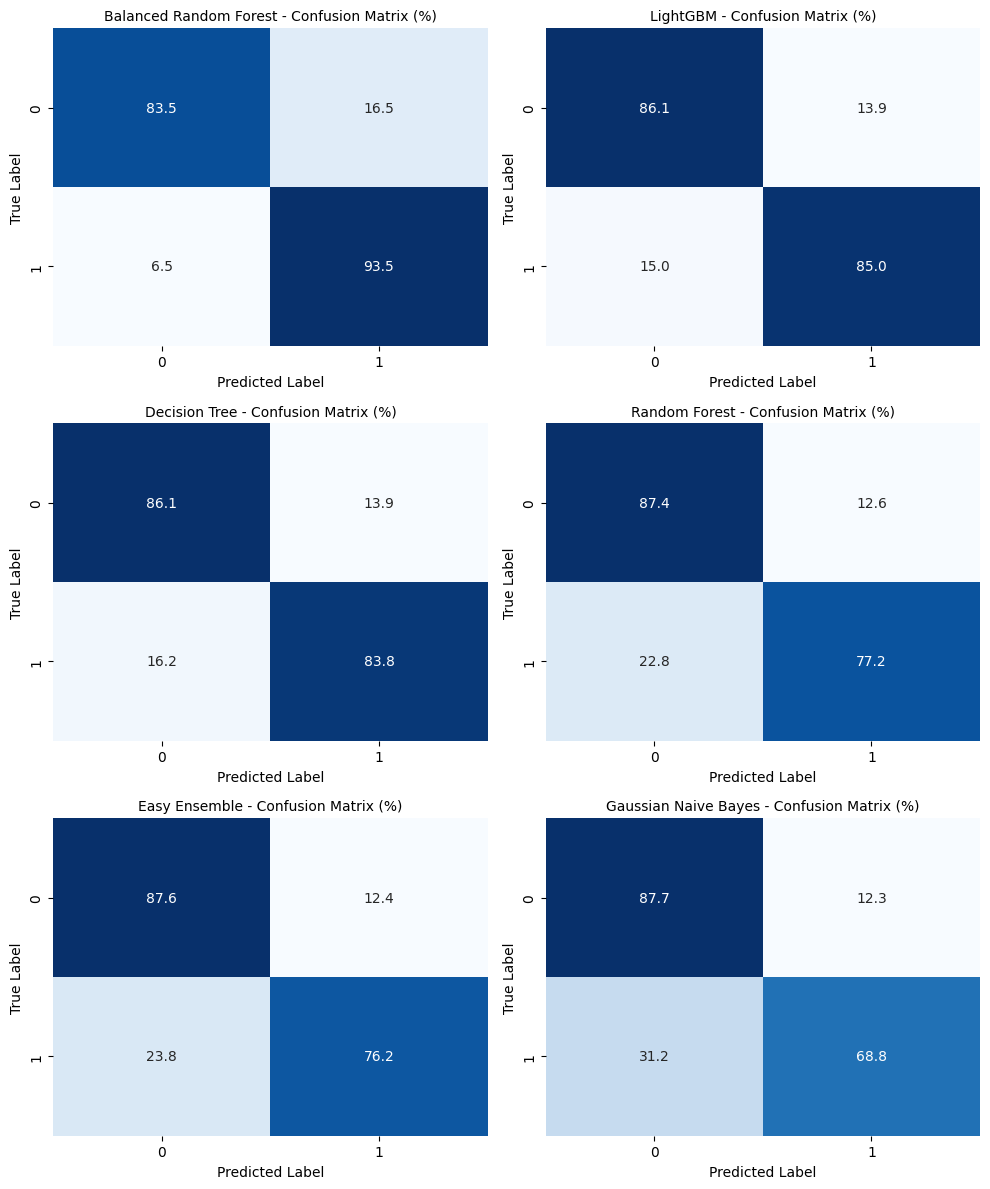

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Top 6 models from original evaluation
top_models = final_df.head(6).index
models_to_plot = []

# Fit and predict
for model_name in top_models:
    for group in all_groups:
        if model_name in group:
            model = group[model_name]
            model.fit(X_train_small, y_train_small)
            y_pred = model.predict(X_test_small)
            models_to_plot.append((model_name, y_pred))
            break

# Plot in grid (2 per row)
n_cols = 2
n_rows = (len(models_to_plot) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))

for idx, (model_name, y_pred) in enumerate(models_to_plot):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]

    cm = confusion_matrix(y_test_small, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_perc, annot=True, fmt=".1f", cmap='Blues',
                xticklabels=np.unique(y_test_small),
                yticklabels=np.unique(y_test_small),
                ax=ax, cbar=False)

    ax.set_title(f"{model_name} - Confusion Matrix (%)", fontsize=10)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

# Remove empty subplot if odd number
if len(models_to_plot) % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()


Test Set Evaluation Summary:
                        Accuracy  Precision    Recall  F1-Score
Dummy Classifier        0.769963   0.592843  0.769963  0.669893
Logistic Regression     0.809016   0.791572  0.809016  0.792061
Decision Tree           0.855879   0.877018  0.855879  0.861941
Random Forest           0.850316   0.862984  0.850316  0.854729
KNN                     0.802775   0.781964  0.802775  0.777323
Gaussian Naive Bayes    0.833518   0.839889  0.833518  0.836208
Gradient Boosting       0.827027   0.819940  0.827027  0.822503
XGBoost                 0.825493   0.817774  0.825493  0.820465
LightGBM                0.858518   0.880630  0.858518  0.864663
Extra Trees             0.810300   0.792785  0.810300  0.791983
Balanced Random Forest  0.857805   0.896965  0.857805  0.866159
Easy Ensemble           0.849531   0.860974  0.849531  0.853640


<Figure size 1200x600 with 0 Axes>

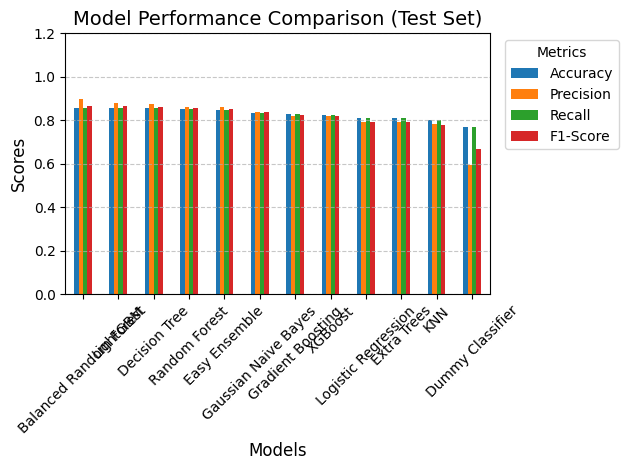

In [14]:
# Convert final test results to DataFrame
final_df = pd.DataFrame(final_test_results).T
final_df = final_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]  # Reorder for consistency

# Save to CSV
final_df.to_csv("final_test_metrics_all_models.csv")

# Print summary
print("Test Set Evaluation Summary:")
print(final_df)

# Sort models by F1-Score for better visual comparison
final_df_sorted = final_df.sort_values(by='F1-Score', ascending=False)

# Plot grouped bar chart of test set performance
plt.figure(figsize=(12, 6))
ax = final_df_sorted.plot(kind='bar')

# Customize bar chart appearance
plt.title('Model Performance Comparison (Test Set)', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')  # Legend outside the plot
plt.tight_layout()
plt.savefig("model_test_performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Convert the final test results into a clean DataFrame
test_results_list = []

# Loop through all final test results
for model_name, metrics in final_df.iterrows():
    row = {
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"]
    }
    test_results_list.append(row)

# Create DataFrame and sort by F1-Score
test_results_df = pd.DataFrame(test_results_list)
test_results_df = test_results_df.sort_values(by="F1-Score", ascending=False)
test_results_df["Rank"] = test_results_df["F1-Score"].rank(ascending=False).astype(int)

# Reset index
test_results_df.reset_index(drop=True, inplace=True)

# Round for readability
test_results_df[["Accuracy", "F1-Score", "Precision", "Recall"]] = test_results_df[
    ["Accuracy", "F1-Score", "Precision", "Recall"]
].round(3)

# Display nicely
from IPython.display import display
display(test_results_df)

# Save to CSV
test_results_df.to_csv("sorted_test_model_performance.csv", index=False)

,Model,Accuracy,F1-Score,Precision,Recall,Rank
0,Balanced Random Forest,0.858,0.866,0.897,0.858,1
1,LightGBM,0.859,0.865,0.881,0.859,2
2,Decision Tree,0.856,0.862,0.877,0.856,3
3,Random Forest,0.850,0.855,0.863,0.850,4
4,Easy Ensemble,0.850,0.854,0.861,0.850,5
5,Gaussian Naive Bayes,0.834,0.836,0.840,0.834,6
6,Gradient Boosting,0.827,0.823,0.820,0.827,7
7,XGBoost,0.825,0.820,0.818,0.825,8
8,Logistic Regression,0.809,0.792,0.792,0.809,9
9,Extra Trees,0.810,0.792,0.793,0.810,10


In [17]:
!pip install seaborn
import seaborn as sns

,Model,Accuracy,F1-Score,Precision,Recall,Rank
0,Balanced Random Forest,0.858,0.866,0.897,0.858,1
1,LightGBM,0.859,0.865,0.881,0.859,2
2,Decision Tree,0.856,0.862,0.877,0.856,3
3,Random Forest,0.850,0.855,0.863,0.850,4
4,Easy Ensemble,0.850,0.854,0.861,0.850,5


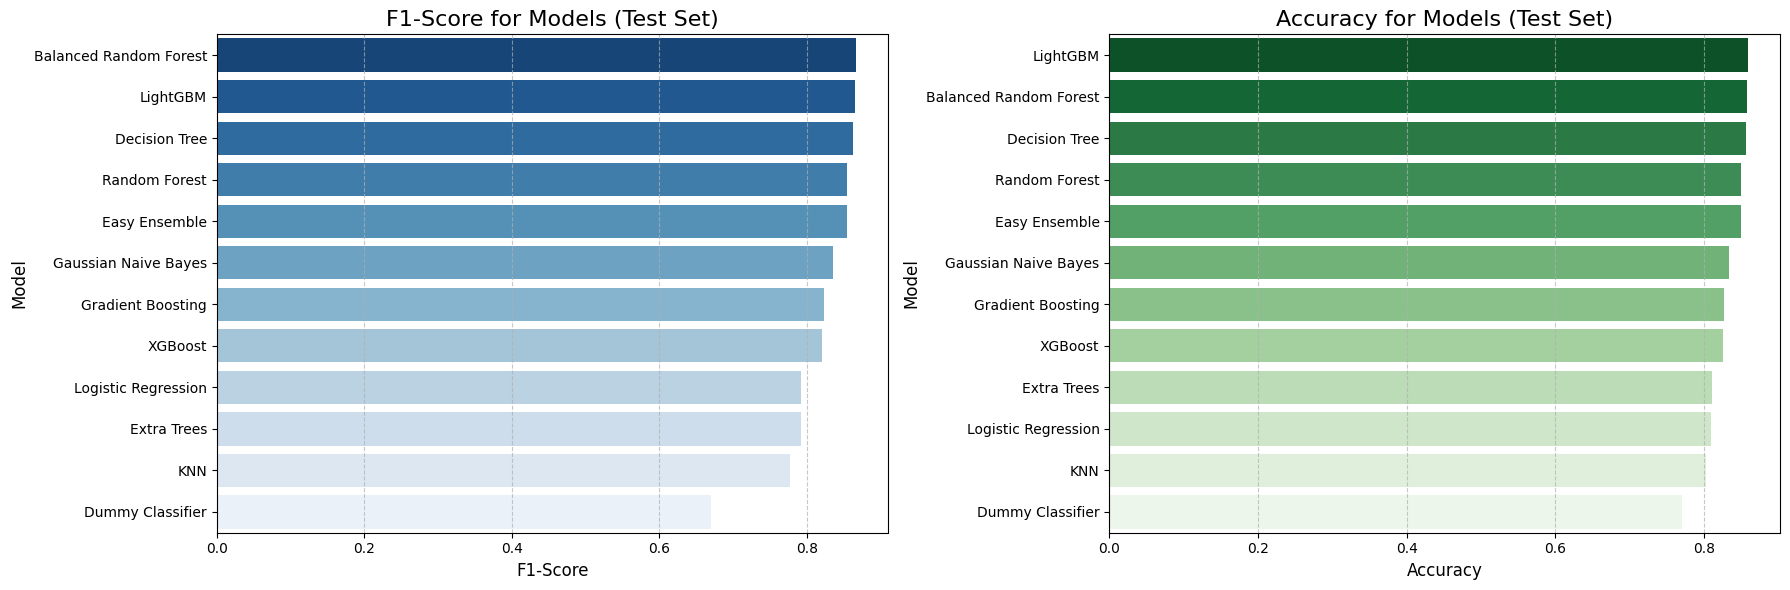

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Optional: Preview the DataFrame before plotting
display(test_results_df.head())

# Sort by F1-Score and Accuracy for clean plots
f1_sorted_df = test_results_df.sort_values(by="F1-Score", ascending=False)
acc_sorted_df = test_results_df.sort_values(by="Accuracy", ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# F1-Score Bar Plot
sns.barplot(
    data=f1_sorted_df,
    x="F1-Score",
    y="Model",
    hue="Model",
    palette="Blues_r",
    dodge=False,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("F1-Score for Models (Test Set)", fontsize=16)
axes[0].set_xlabel('F1-Score', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Accuracy Bar Plot
sns.barplot(
    data=acc_sorted_df,
    x='Accuracy',
    y='Model',
    hue='Model',
    palette="Greens_r",
    dodge=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Accuracy for Models (Test Set)", fontsize=16)
axes[1].set_xlabel('Accuracy', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# Final layout and save
plt.tight_layout()
plt.savefig("f1_accuracy_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Cost-Sensitive Models: Evaluation Without Resampling

In [19]:
# === Cost-Sensitive Models Evaluation ===
print("\n=== Evaluating Cost-Sensitive Models ===")

cost_sensitive_group = {
    'Cost-Sensitive Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Cost-Sensitive Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42),
    'Cost-Sensitive Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=25, max_depth=10, n_jobs=-1, random_state=42),
    'Cost-Sensitive Gradient Boosting': GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42),  # no native class_weight
    'Cost-Sensitive LightGBM': LGBMClassifier(class_weight='balanced', n_estimators=50, learning_rate=0.1, max_depth=10, random_state=42, n_jobs=-1),
}

# Evaluate using the same 20% CV set
cs_results = evaluate_models(cost_sensitive_group, X_cv_sample, y_cv_sample, skf, scoring)
cs_results.to_csv("cost_sensitive_model_results.csv")
display(cs_results)

# Final evaluation on test set
cs_test_results = {}
for name, model in cost_sensitive_group.items():
    model.fit(X_train_small, y_train_small)
    y_pred = model.predict(X_test_small)
    cs_test_results[name] = {
        'Accuracy': accuracy_score(y_test_small, y_pred),
        'Precision': precision_score(y_test_small, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_small, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test_small, y_pred, average='weighted', zero_division=0)
    }

# Save and display
cs_final_df = pd.DataFrame(cs_test_results).T.sort_values(by='F1-Score', ascending=False)
cs_final_df.to_csv("cost_sensitive_test_results.csv")
display(cs_final_df)



=== Evaluating Cost-Sensitive Models ===
Evaluating Cost-Sensitive Logistic Regression...
Evaluating Cost-Sensitive Decision Tree...
Evaluating Cost-Sensitive Random Forest...
Evaluating Cost-Sensitive Gradient Boosting...
Evaluating Cost-Sensitive LightGBM...


,Accuracy,Precision,Recall,F1-Score
Cost-Sensitive Logistic Regression,0.794481,0.831365,0.794481,0.805409
Cost-Sensitive Decision Tree,0.853462,0.871439,0.853462,0.858997
Cost-Sensitive Random Forest,0.863270,0.893236,0.863270,0.870345
Cost-Sensitive Gradient Boosting,0.834470,0.828104,0.834470,0.830297
Cost-Sensitive LightGBM,0.867014,0.902729,0.867014,0.874557


,Accuracy,Precision,Recall,F1-Score
Cost-Sensitive LightGBM,0.862798,0.903572,0.862798,0.871042
Cost-Sensitive Decision Tree,0.862442,0.890952,0.862442,0.869382
Cost-Sensitive Random Forest,0.857021,0.894936,0.857021,0.865290
Cost-Sensitive Gradient Boosting,0.827027,0.819940,0.827027,0.822503
Cost-Sensitive Logistic Regression,0.789757,0.827570,0.789757,0.801065


## Compare Baseline vs Cost-Sensitive Models

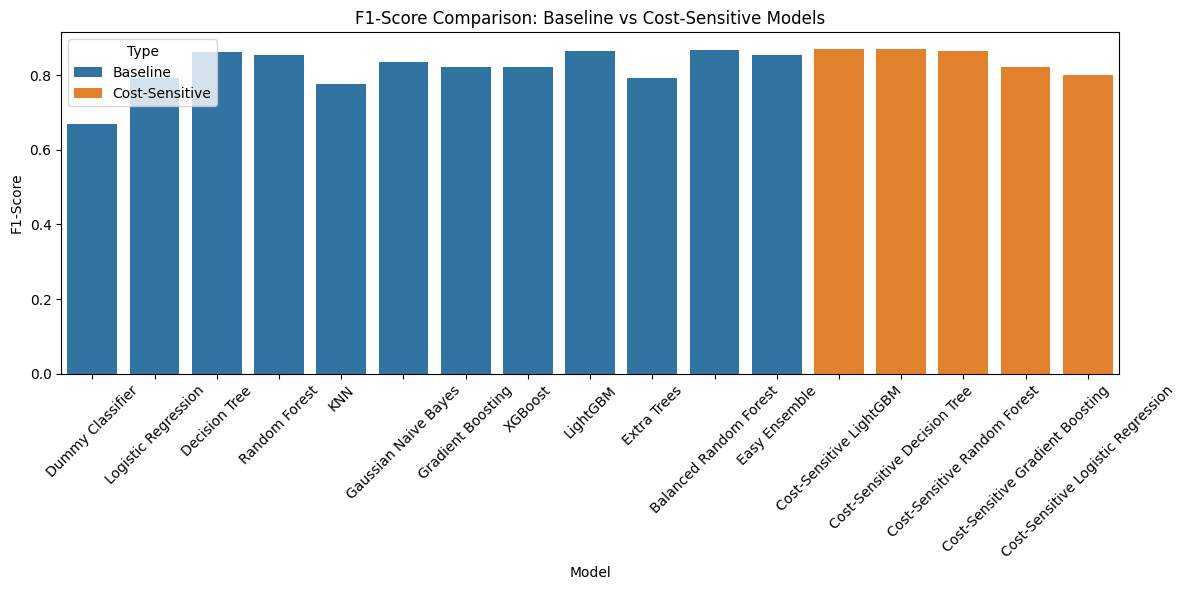

In [20]:
# Combine baseline and cost-sensitive results
baseline_df = final_df.copy()
baseline_df['Type'] = 'Baseline'
cs_final_df['Type'] = 'Cost-Sensitive'

comparison_df = pd.concat([baseline_df, cs_final_df])
comparison_df.reset_index(inplace=True)
comparison_df.rename(columns={'index': 'Model'}, inplace=True)

# Plot F1-Score comparison
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Model', y='F1-Score', hue='Type')
plt.title("F1-Score Comparison: Baseline vs Cost-Sensitive Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Defining Imbalance Handling Techniques (Over-, Under-, and Hybrid Sampling)

In [ ]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import (
    RandomUnderSampler, TomekLinks, ClusterCentroids, NearMiss,
    EditedNearestNeighbours, CondensedNearestNeighbour,
    OneSidedSelection, NeighbourhoodCleaningRule
)
from imblearn.combine import SMOTETomek, SMOTEENN

neighbors = 3  # SMOTE and similar methods need this

imbalance_methods = {
    "Original Data": None,
    f"SMOTE (k={neighbors})": SMOTE(random_state=42, k_neighbors=neighbors),
    f"ADASYN (k={neighbors})": ADASYN(random_state=42, n_neighbors=neighbors),
    f"Borderline-SMOTE (k={neighbors})": BorderlineSMOTE(random_state=42, k_neighbors=neighbors),
    "Random Oversampling": RandomOverSampler(random_state=42),

    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "NearMiss": NearMiss(version=1),
    "Cluster Centroids": ClusterCentroids(random_state=42),
    "Edited Nearest Neighbours": EditedNearestNeighbours(n_neighbors=3),
    #"Condensed Nearest Neighbour": CondensedNearestNeighbour(random_state=42),
    #"One-Sided Selection": OneSidedSelection(random_state=42),
    #"Neighbourhood Cleaning Rule": NeighbourhoodCleaningRule(n_neighbors=3),

    #"SMOTETomek": SMOTETomek(random_state=42),
    #"SMOTEENN": SMOTEENN(random_state=42),
}

## 16. Model Evaluation After Imbalance Handling (on Subsampled Data)

In [11]:
imbalance_results = {}

# Set the pre-sampling ratio (how much of original X_train to use)
pre_sample_ratio = 0.2  # 20% of original training data

# Subsample once from original training data
X_train_subset, _, y_train_subset, _ = train_test_split(
    X_train, y_train, train_size=pre_sample_ratio, stratify=y_train, random_state=42
)

for method_name, sampler in imbalance_methods.items():
    print(f"\n Applying: {method_name}")

    # 1. Apply imbalance handling on the subset only
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X_train_subset, y_train_subset)
    else:
        X_resampled, y_resampled = X_train_subset.copy(), y_train_subset.copy()

    # 2. Subsample (again) for evaluation (optional if needed smaller)
    eval_sample_ratio = 0.5  # use 50% of resampled subset for CV to save more time
    X_resampled_small, _, y_resampled_small, _ = train_test_split(
        X_resampled, y_resampled, train_size=eval_sample_ratio, stratify=y_resampled, random_state=42
    )

    # 3. Evaluate models using CV on resampled small data
    method_results = []
    for i, group in enumerate(all_groups, 1):
        print(f"  → Evaluating group {i} models...")
        result = evaluate_models(group, X_resampled_small, y_resampled_small, skf, scoring)
        result.to_csv(f"resampled_{method_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}_group{i}.csv")
        method_results.append(result)

    # 4. Combine and store results
    combined = pd.concat(method_results)
    imbalance_results[method_name] = combined
    combined.to_csv(f"resampled_results_{method_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.csv")


 Applying: Original Data
  → Evaluating group 1 models...
Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
  → Evaluating group 2 models...
Evaluating KNN...
Evaluating Gaussian Naive Bayes...
  → Evaluating group 3 models...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
  → Evaluating group 4 models...
Evaluating Extra Trees...
Evaluating Balanced Random Forest...
Evaluating Easy Ensemble...

 Applying: SMOTE (k=3)
  → Evaluating group 1 models...
Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
  → Evaluating group 2 models...
Evaluating KNN...
Evaluating Gaussian Naive Bayes...
  → Evaluating group 3 models...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
  → Evaluating group 4 models...
Evaluating Extra Trees...
Evaluating Balanced Random Forest...
Evaluating Easy Ensemble...

 

In [12]:
# Convert all imbalance_results into a unified DataFrame
summary_list = []

for method_name, df in imbalance_results.items():
    for model_name, metrics in df.iterrows():
        summary_list.append({
            "Imbalance Technique": method_name,
            "Model": model_name,
            "Accuracy": metrics["Accuracy"],
            "F1-Score": metrics["F1-Score"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"]
        })

# Create DataFrame
imbalance_summary_df = pd.DataFrame(summary_list)

# Sort for readability
imbalance_summary_df = imbalance_summary_df.sort_values(by=["Imbalance Technique", "F1-Score"], ascending=[True, False])
imbalance_summary_df.reset_index(drop=True, inplace=True)

# Save and display
imbalance_summary_df.to_csv("imbalance_technique_model_summary.csv", index=False)
from IPython.display import display
display(imbalance_summary_df)

,Imbalance Technique,Model,Accuracy,F1-Score,Precision,Recall
0,ADASYN (k=3),LightGBM,0.900261,0.899814,0.904978,0.900261
1,ADASYN (k=3),Random Forest,0.884208,0.883881,0.886711,0.884208
2,ADASYN (k=3),Balanced Random Forest,0.883858,0.883516,0.886472,0.883858
3,ADASYN (k=3),KNN,0.874454,0.874455,0.874463,0.874454
4,ADASYN (k=3),Decision Tree,0.865107,0.864920,0.866004,0.865107
...,...,...,...,...,...,...
115,Tomek Links,XGBoost,0.843490,0.840145,0.838312,0.843490
116,Tomek Links,Extra Trees,0.824135,0.810946,0.811769,0.824135
117,Tomek Links,Logistic Regression,0.815895,0.801398,0.801694,0.815895
118,Tomek Links,KNN,0.803845,0.774053,0.787287,0.803845


## Normalized Confusion Matrices Before Imbalance Handling

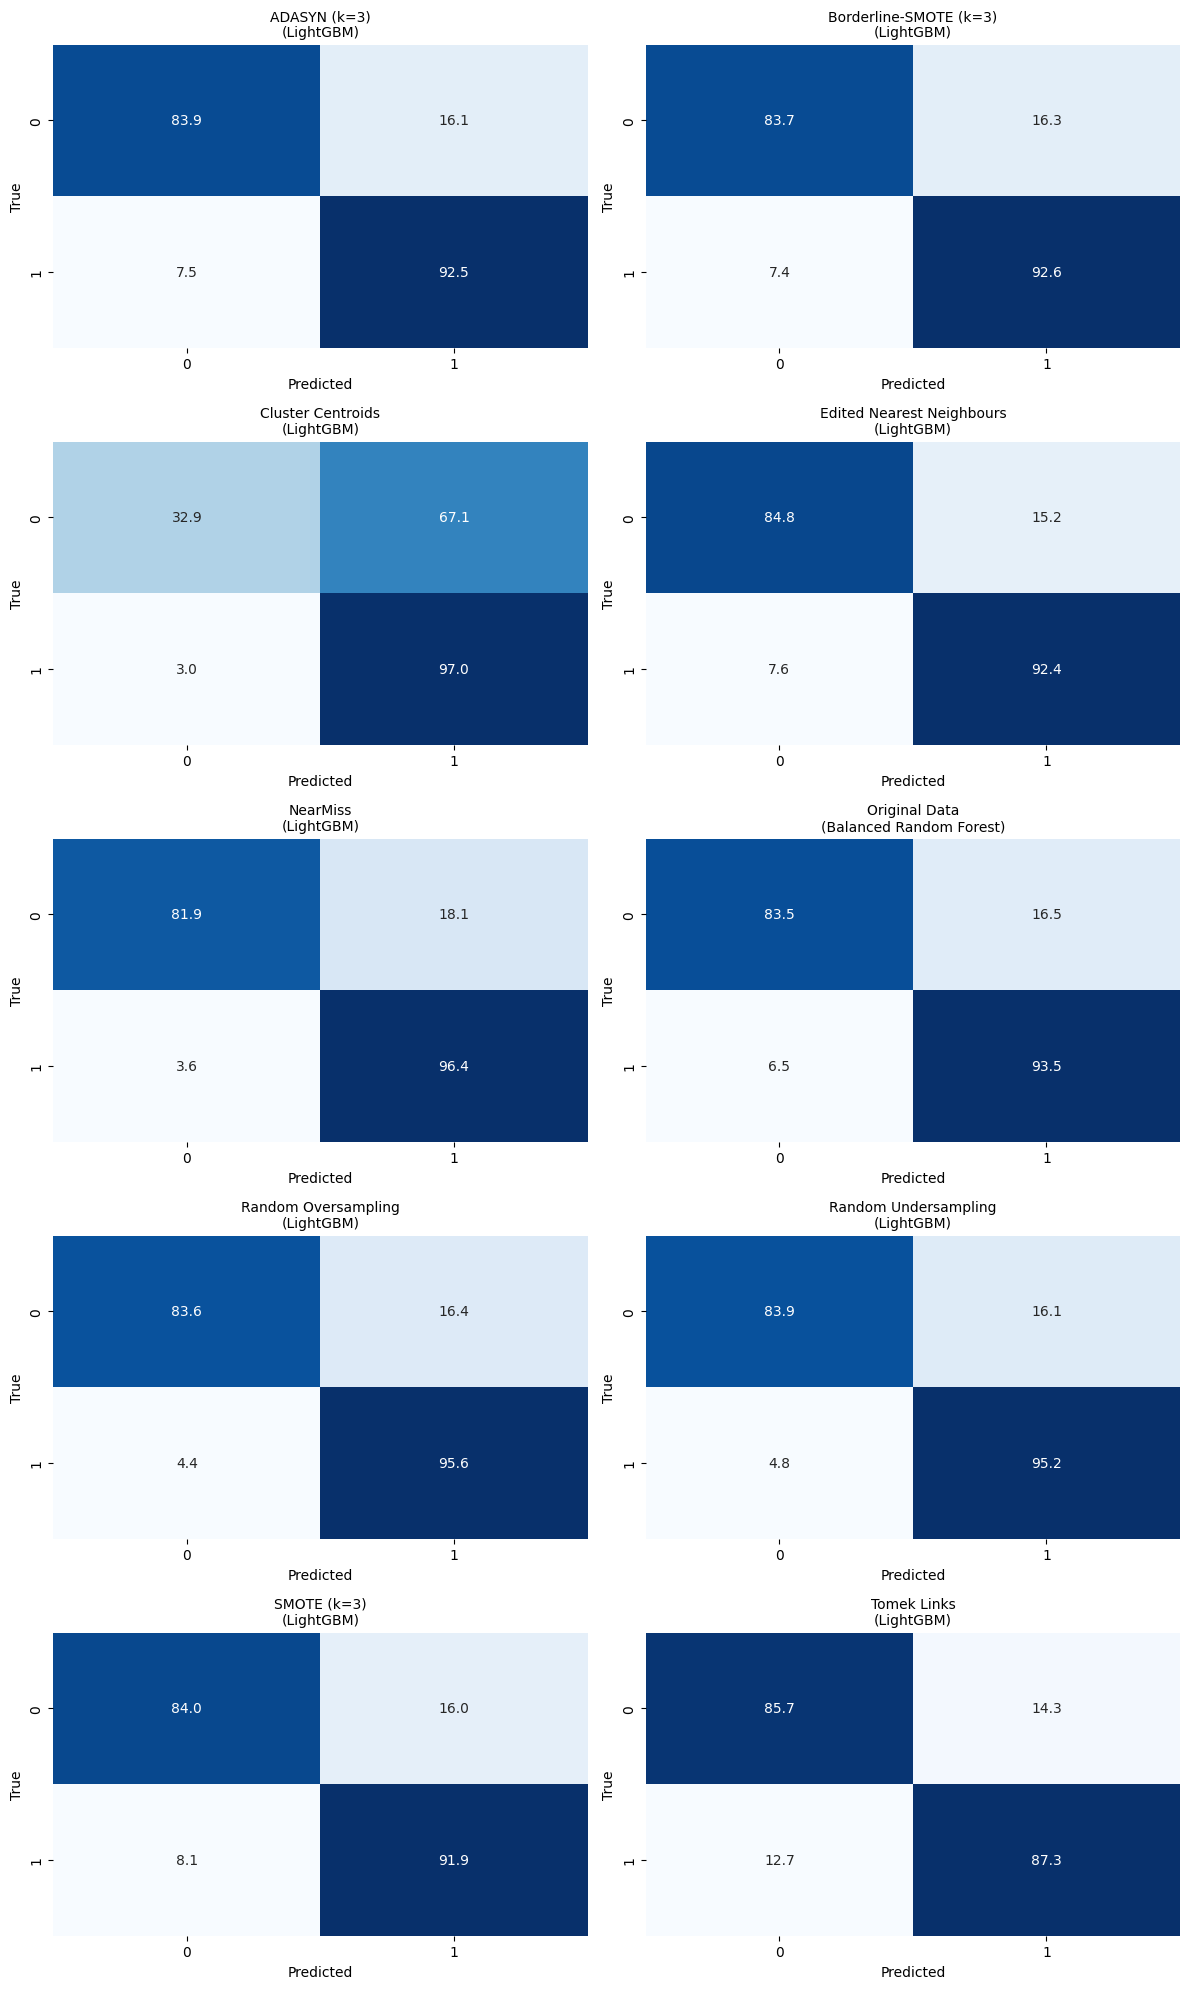

In [21]:
top_models_per_technique = imbalance_summary_df.groupby("Imbalance Technique").first().reset_index()
plots = []

for _, row in top_models_per_technique.iterrows():
    technique = row["Imbalance Technique"]
    model_name = row["Model"]

    # Get model
    for group in all_groups:
        if model_name in group:
            model = group[model_name]
            break

    # Resample training data for the technique
    if technique == "Original Data":
        X_resampled, y_resampled = X_train_subset.copy(), y_train_subset.copy()
    else:
        sampler = imbalance_methods[technique]
        X_resampled, y_resampled = sampler.fit_resample(X_train_subset, y_train_subset)

    # Fit and predict
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_small)

    # Confusion matrix as percentage
    cm = confusion_matrix(y_test_small, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plots.append((f"{technique}\n({model_name})", cm_perc))

# Plot all confusion matrices in grid (2 per row)
n_cols = 2
n_rows = (len(plots) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

for idx, (title, cm_perc) in enumerate(plots):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]

    sns.heatmap(cm_perc, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=np.unique(y_test_small),
                yticklabels=np.unique(y_test_small),
                ax=ax, cbar=False)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# Remove extra subplot if odd number
if len(plots) % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()

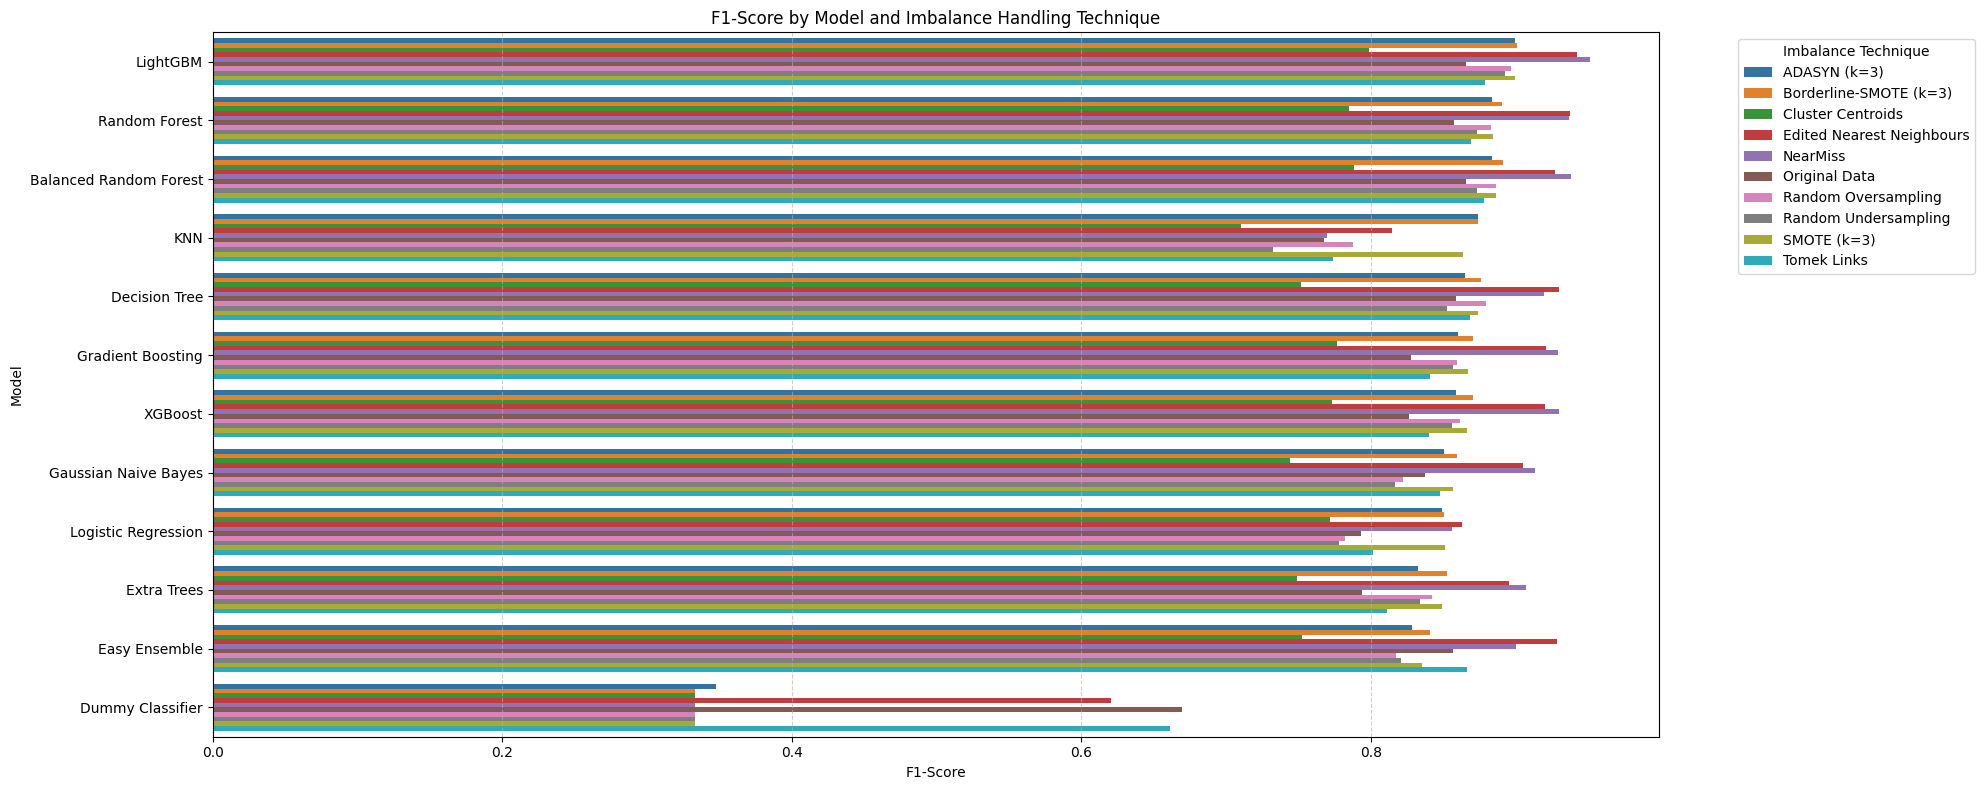

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
sns.barplot(data=imbalance_summary_df, x="F1-Score", y="Model", hue="Imbalance Technique", dodge=True)
plt.title("F1-Score by Model and Imbalance Handling Technique")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.legend(title="Imbalance Technique", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("imbalance_techniques_model_comparison.png", dpi=300)
plt.show()

In [23]:
top_combo = imbalance_summary_df.sort_values(by="F1-Score", ascending=False).head(10)
display(top_combo)

,Imbalance Technique,Model,Accuracy,F1-Score,Precision,Recall
48,NearMiss,LightGBM,0.951556,0.951551,0.951739,0.951556
36,Edited Nearest Neighbours,LightGBM,0.942299,0.942778,0.943740,0.942299
49,NearMiss,Balanced Random Forest,0.938418,0.938415,0.938516,0.938418
37,Edited Nearest Neighbours,Random Forest,0.937274,0.937346,0.937428,0.937274
50,NearMiss,Random Forest,0.936945,0.936945,0.936957,0.936945
51,NearMiss,XGBoost,0.930047,0.930003,0.931128,0.930047
38,Edited Nearest Neighbours,Decision Tree,0.930035,0.929952,0.929898,0.930035
52,NearMiss,Gradient Boosting,0.929388,0.929343,0.930491,0.929388
39,Edited Nearest Neighbours,Easy Ensemble,0.929043,0.928617,0.928431,0.929043
40,Edited Nearest Neighbours,Balanced Random Forest,0.925672,0.927410,0.933518,0.925672


In [25]:
# === Cost-Sensitive Models Evaluation After Imbalance Handling ===

cost_sensitive_results = {}

# Define cost-sensitive models
cost_sensitive_models = {
    'Cost-Sensitive Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Cost-Sensitive Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42),
    'Cost-Sensitive Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=25, max_depth=10, n_jobs=-1, random_state=42),
}

# Subsample original training set once (20%)
pre_sample_ratio = 0.2
X_train_subset, _, y_train_subset, _ = train_test_split(
    X_train, y_train, train_size=pre_sample_ratio, stratify=y_train, random_state=42
)

for method_name, sampler in imbalance_methods.items():
    print(f"\n Evaluating Cost-Sensitive Models with: {method_name}")

    # 1. Apply imbalance technique
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X_train_subset, y_train_subset)
    else:
        X_resampled, y_resampled = X_train_subset.copy(), y_train_subset.copy()

    # 2. Optional further subsample to speed up training
    X_resampled_small, _, y_resampled_small, _ = train_test_split(
        X_resampled, y_resampled, train_size=0.5, stratify=y_resampled, random_state=42
    )

    # 3. Evaluate all cost-sensitive models
    result = evaluate_models(cost_sensitive_models, X_resampled_small, y_resampled_small, skf, scoring)

    # 4. Save
    result.to_csv(f"cost_sensitive_results_{method_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.csv")
    cost_sensitive_results[method_name] = result

# Optional: Create a summary DataFrame
cs_summary = []
for method, df in cost_sensitive_results.items():
    for model_name, metrics in df.iterrows():
        cs_summary.append({
            "Imbalance Technique": method,
            "Model": model_name,
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1-Score": metrics["F1-Score"]
        })

cost_sensitive_summary_df = pd.DataFrame(cs_summary)
cost_sensitive_summary_df = cost_sensitive_summary_df.sort_values(by=["Imbalance Technique", "F1-Score"], ascending=[True, False])
cost_sensitive_summary_df.to_csv("cost_sensitive_summary.csv", index=False)

from IPython.display import display
display(cost_sensitive_summary_df)


 Evaluating Cost-Sensitive Models with: Original Data
Evaluating Cost-Sensitive Logistic Regression...
Evaluating Cost-Sensitive Decision Tree...
Evaluating Cost-Sensitive Random Forest...

 Evaluating Cost-Sensitive Models with: SMOTE (k=3)
Evaluating Cost-Sensitive Logistic Regression...
Evaluating Cost-Sensitive Decision Tree...
Evaluating Cost-Sensitive Random Forest...

 Evaluating Cost-Sensitive Models with: ADASYN (k=3)
Evaluating Cost-Sensitive Logistic Regression...
Evaluating Cost-Sensitive Decision Tree...
Evaluating Cost-Sensitive Random Forest...

 Evaluating Cost-Sensitive Models with: Borderline-SMOTE (k=3)
Evaluating Cost-Sensitive Logistic Regression...
Evaluating Cost-Sensitive Decision Tree...
Evaluating Cost-Sensitive Random Forest...

 Evaluating Cost-Sensitive Models with: Random Oversampling
Evaluating Cost-Sensitive Logistic Regression...
Evaluating Cost-Sensitive Decision Tree...
Evaluating Cost-Sensitive Random Forest...

 Evaluating Cost-Sensitive Models wit

,Imbalance Technique,Model,Accuracy,Precision,Recall,F1-Score
8,ADASYN (k=3),Cost-Sensitive Random Forest,0.882638,0.884700,0.882638,0.882351
7,ADASYN (k=3),Cost-Sensitive Decision Tree,0.864948,0.865822,0.864948,0.864765
6,ADASYN (k=3),Cost-Sensitive Logistic Regression,0.849008,0.850869,0.849008,0.848964
11,Borderline-SMOTE (k=3),Cost-Sensitive Random Forest,0.890892,0.895119,0.890892,0.890600
10,Borderline-SMOTE (k=3),Cost-Sensitive Decision Tree,0.876058,0.877560,0.876058,0.875934
9,Borderline-SMOTE (k=3),Cost-Sensitive Logistic Regression,0.850617,0.851653,0.850617,0.850506
26,Cluster Centroids,Cost-Sensitive Random Forest,0.793164,0.838710,0.793164,0.785965
24,Cluster Centroids,Cost-Sensitive Logistic Regression,0.779134,0.818786,0.779134,0.772066
25,Cluster Centroids,Cost-Sensitive Decision Tree,0.755881,0.775128,0.755881,0.751487
29,Edited Nearest Neighbours,Cost-Sensitive Random Forest,0.933758,0.938375,0.933758,0.934903


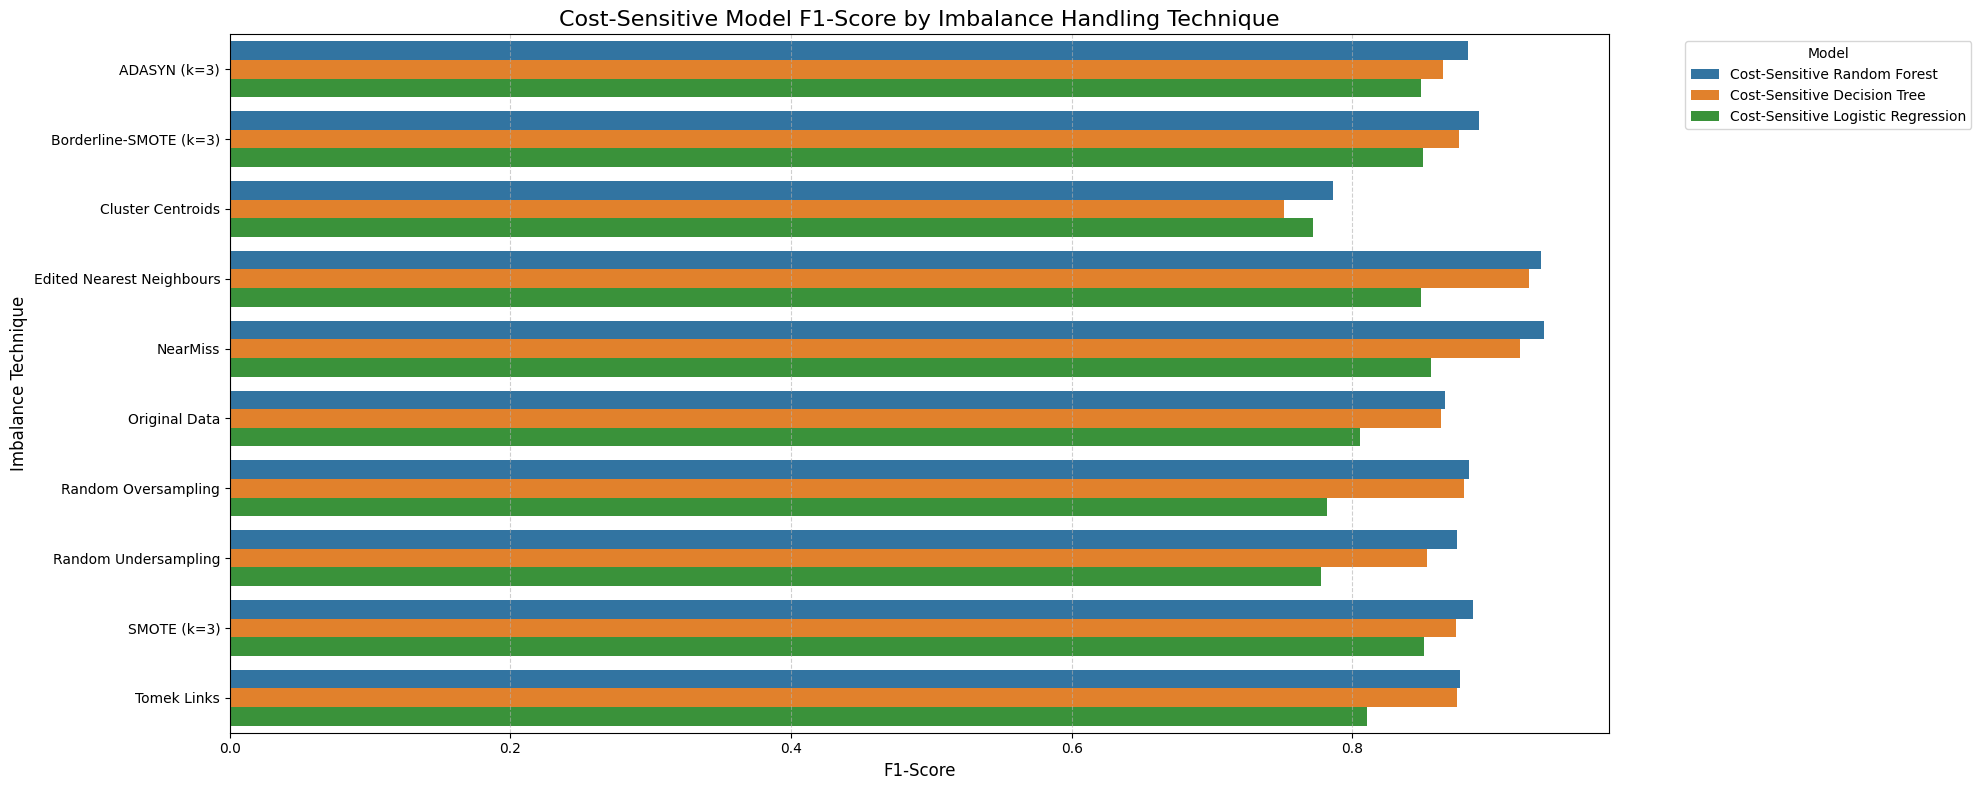

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort by F1-Score within each technique for consistent bars
plot_df = cost_sensitive_summary_df.sort_values(by=["Imbalance Technique", "F1-Score"], ascending=[True, False])

# Set figure size
plt.figure(figsize=(20, 8))

# Create bar plot
sns.barplot(
    data=plot_df,
    x="F1-Score",
    y="Imbalance Technique",
    hue="Model",
    dodge=True
)

# Customize the plot
plt.title("Cost-Sensitive Model F1-Score by Imbalance Handling Technique", fontsize=16)
plt.xlabel("F1-Score", fontsize=12)
plt.ylabel("Imbalance Technique", fontsize=12)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot if needed
plt.savefig("cost_sensitive_f1_scores_by_technique.png", dpi=300)
plt.show()


In [27]:
# Add a Type column to distinguish between Baseline and Cost-Sensitive
imbalance_summary_df["Type"] = "Baseline"
cost_sensitive_summary_df["Type"] = "Cost-Sensitive"

# Standardize column names
baseline_cols = ["Imbalance Technique", "Model", "Accuracy", "Precision", "Recall", "F1-Score", "Type"]
cost_sensitive_cols = baseline_cols  # already matched
combined_imbalance_df = pd.concat([
    imbalance_summary_df[baseline_cols],
    cost_sensitive_summary_df[cost_sensitive_cols]
])

# Reset index
combined_imbalance_df.reset_index(drop=True, inplace=True)


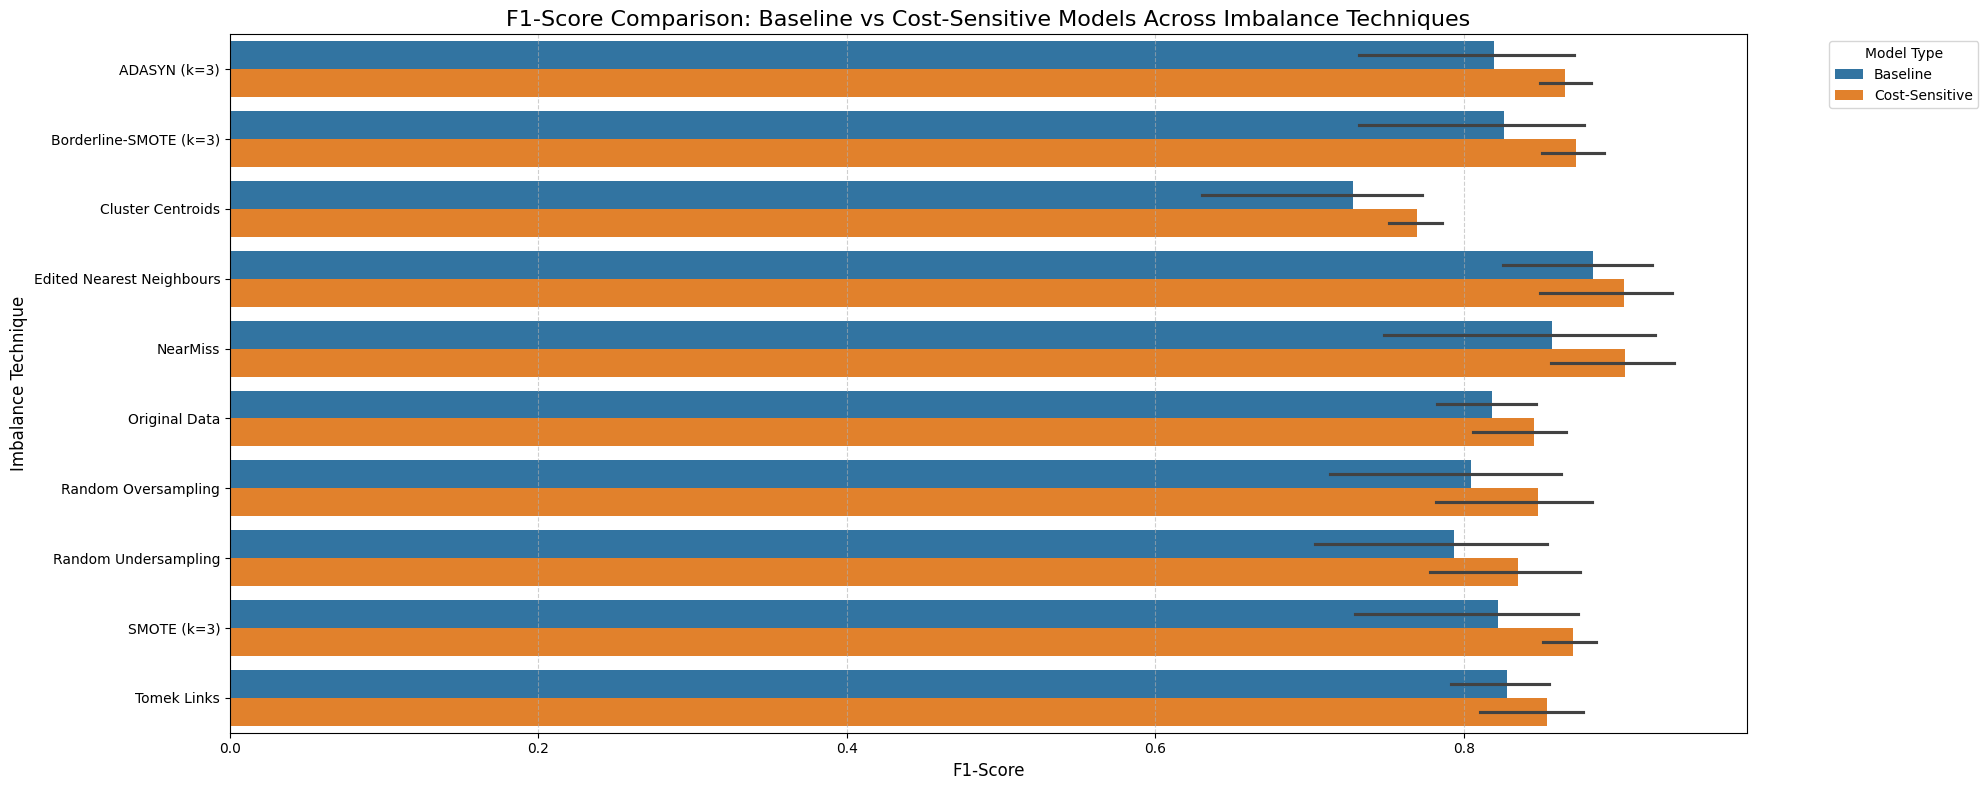

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
sns.barplot(
    data=combined_imbalance_df,
    x="F1-Score",
    y="Imbalance Technique",
    hue="Type",
    dodge=True
)

plt.title("F1-Score Comparison: Baseline vs Cost-Sensitive Models Across Imbalance Techniques", fontsize=16)
plt.xlabel("F1-Score", fontsize=12)
plt.ylabel("Imbalance Technique", fontsize=12)
plt.legend(title="Model Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("f1score_comparison_imbalance_vs_cost.png", dpi=300)
plt.show()
